In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
def stochastic_shm_sde(n_timesteps, dt, b, w, sigma_q=1.0, m_0=np.zeros(2), P_0=np.eye(2), sub_step=10):
    F = np.array([[0, 1], [- w * w, -b]])
    L = np.array([0, 1])
    
    t_T = np.zeros(n_timesteps + 1)
    x_T = np.zeros((n_timesteps + 1, 2))
    
    x_T[0] = np.random.multivariate_normal(m_0, P_0)
    d_dt = dt / sub_step
    
    for t in range(1, n_timesteps + 1):
        x_int = x_T[t - 1]
        
        for _ in range(sub_step):
            eps_t = sigma_q * np.random.randn() * np.sqrt(d_dt)
            dx_t = np.matmul(F, x_int) * d_dt + L * eps_t
            x_int = x_int + dx_t
            
        x_T[t] = x_int
        t_T[t] = t_T[t - 1] + dt
    
    return x_T, t_T

In [3]:
n_timesteps = 1000
dt = 0.01
b = 2.0
w = 4.0
sigma_q = 0.5
sigma_r = 1.0
sub_step = 10

In [4]:
x_T, t_T = stochastic_shm_sde(n_timesteps, dt, b, w, sigma_q, sub_step=sub_step)

In [54]:
alpha=0.1

t_start = 0.0
t_end = 10.0

In [55]:
x_0 = 1

num_iterations = 10000

N = 10000  #Compute in 10000 grid points

dt = (t_end - t_start)/N

In [67]:
time = np.arange(t_start, t_end, dt)  

noise = np.sqrt(alpha)*np.random.normal(0,1,(N, num_iterations))*np.sqrt(dt)
x = np.zeros_like(increment_array)

solution[0] = x_0

for t in range(1, N):
    x[t] = x[t-1] + (-x[t-1])*dt + noise[t]

Text(0, 0.5, 'x(t)')

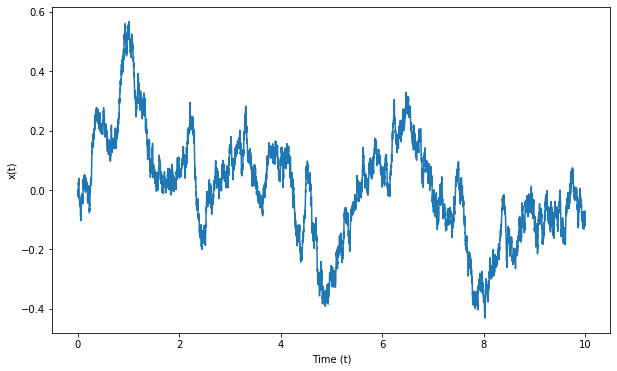

In [68]:
plt.figure(figsize=(10,6))
plt.plot(time, x[:,0:1])

plt.xlabel('Time (t)', size = 10)
plt.ylabel('x(t)', size = 10)
